# Teste de Baseline com regressão linear para predição de resistência à compressão

In [ ]:
%%capture
!pip install optuna

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'

# Regressão linear simples
simples_file = 'df_resistencia_RL.pkl'
simples_path = os.path.join(dirpath, simples_file)

df_simples = pd.read_pickle(simples_path)
df_simples['target'] = df_simples['Resistencia_Compressao_MPa'].copy()
df_simples.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear Lasso
lasso_file = 'df_resistencia_Lasso.pkl'
lasso_path = os.path.join(dirpath, lasso_file)

df_lasso = pd.read_pickle(lasso_path)
df_lasso['target'] = df_lasso['Resistencia_Compressao_MPa'].copy()
df_lasso.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear Ridge
ridge_file = 'df_resistencia_Ridge.pkl'
ridge_path = os.path.join(dirpath, ridge_file)

df_ridge = pd.read_pickle(ridge_path)
df_ridge['target'] = df_ridge['Resistencia_Compressao_MPa'].copy()
df_ridge.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear ElasticNet
elasticnet_file = 'df_resistencia_ElasticNet.pkl'
elasticnet_path = os.path.join(dirpath, elasticnet_file)

df_elasticnet = pd.read_pickle(elasticnet_path)
df_elasticnet['target'] = df_elasticnet['Resistencia_Compressao_MPa'].copy()
df_elasticnet.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

In [ ]:
df_simples.shape, df_lasso.shape, df_ridge.shape, df_elasticnet.shape

((466, 27), (466, 71), (466, 20), (466, 17))

## Teste com Regressão simples

In [ ]:
n_groups = df_simples['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


In [ ]:
all_preds = []
all_true = []
all_groups = []

X = df_simples.drop(
    columns=["target", "Autores/ano"]
)

y = df_simples["target"]
groups = df_simples["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = LinearRegression()

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [ ]:
lr_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lr_results["residual"] = (
    lr_results["y_true"] -
    lr_results["y_pred"]
)

lr_results["abs_error"] = (
    lr_results["residual"].abs()
)

## Observado vs Predito

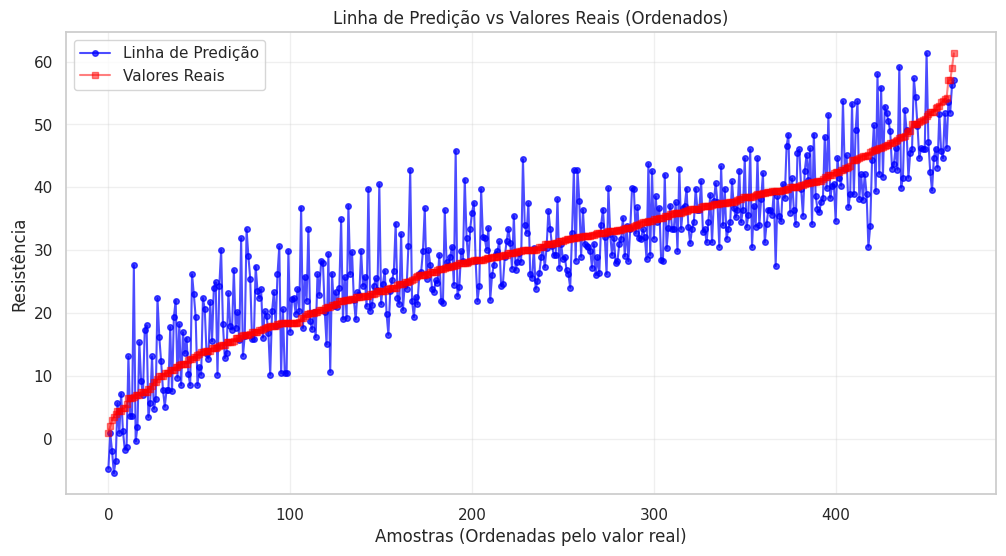

In [ ]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lr_results.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

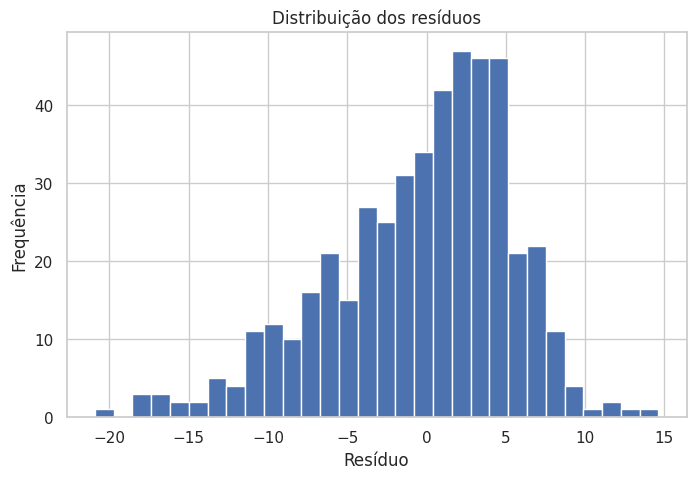

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    lr_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

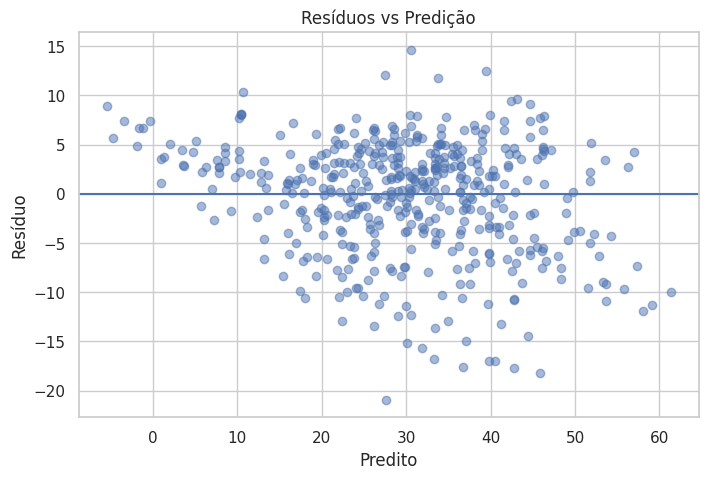

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    lr_results["y_pred"],
    lr_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

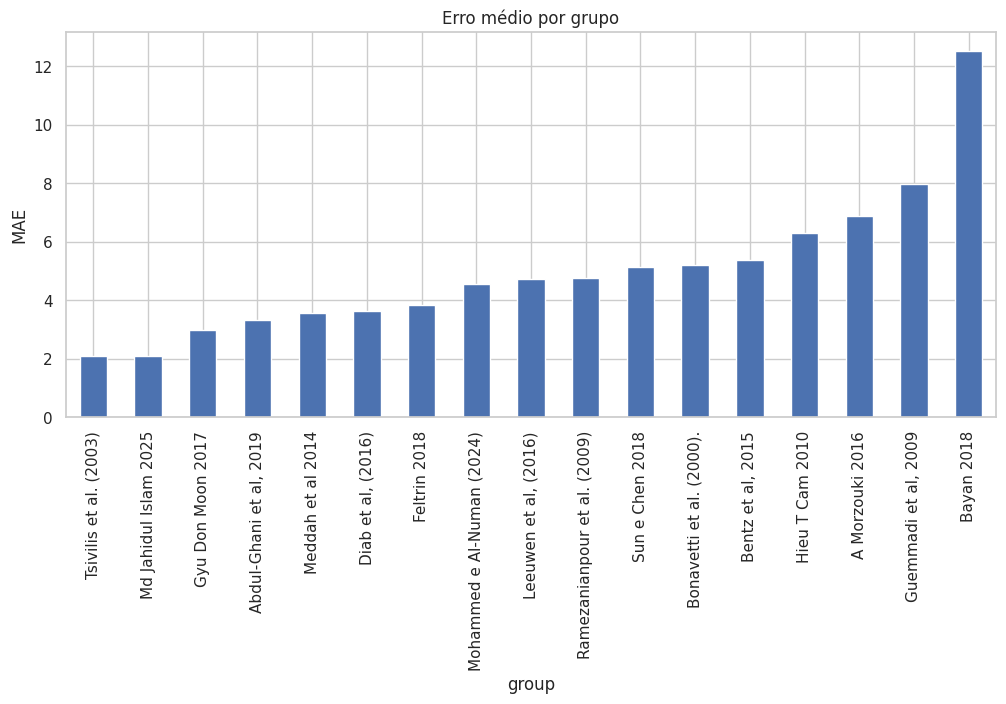

In [ ]:
group_errors = (
    lr_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [ ]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.7877
mean_absolute_error: 4.5529
mean_absolute_percentage_error: 0.2309
R² Score: 77.3513


# Teste com regressão Lasso

In [ ]:
X = df_lasso.drop(
    columns=["target", "Autores/ano"]
)

y = df_lasso["target"]
groups = df_lasso["Autores/ano"]

def objective(trial):
    rmse_scores = []

    alpha = trial.suggest_float("alpha", 0.01, 10)
    
    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = Lasso(alpha=alpha, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [ ]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Lasso")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_lasso = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_lasso.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]   
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_lasso.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_lasso.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Lasso:   0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-06-07 03:36:28,948] A new study created in memory with name: Tuning_Concreto
[I 2026-06-07 03:36:29,085] Trial 0 finished with value: 6.904445890501841 and parameters: {'alpha': 5.125549882663294}. Best is trial 0 with value: 6.904445890501841.
[I 2026-06-07 03:36:29,206] Trial 1 finished with value: 6.421824694630139 and parameters: {'alpha': 4.277351311114494}. Best is trial 1 with value: 6.421824694630139.
[I 2026-06-07 03:36:29,329] Trial 2 finished with value: 9.974129181038112 and parameters: {'alpha': 9.511513719952974}. Best is trial 1 with value: 6.421824694630139.
[I 2026-06-07 03:36:29,452] Trial 3 finished with value: 5.663416244090577 and parameters: {'alpha': 2.0451835769300932}. Best is trial 3 with value: 5.663416244090577.
[I 2026-06-07 03:36:29,577] Trial 4 finished with value: 9.374004700181278 and parameters: {'alpha': 8.656676874151483}. Best is trial 3 with value: 5.663416244090577.
[I 2026-06-07 03:36:29,702] Trial 5 finished with value: 8.088970904640437

Melhor RMSE alcançado (Cross-Validation): 5.0644
Melhores Hiperparâmetros encontrados:
  'alpha': 0.9020353374289296,


In [ ]:
all_preds = []
all_true = []
all_groups = []

X = df_lasso.drop(  
    columns=["target", "Autores/ano"]
)

y = df_lasso["target"]
groups = df_lasso["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = Lasso(alpha=study_lasso.best_params["alpha"], random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [ ]:
lasso_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lasso_results["residual"] = (
    lasso_results["y_true"] -
    lasso_results["y_pred"]
)

lasso_results["abs_error"] = (
    lasso_results["residual"].abs()
)

## Observado vs Predito

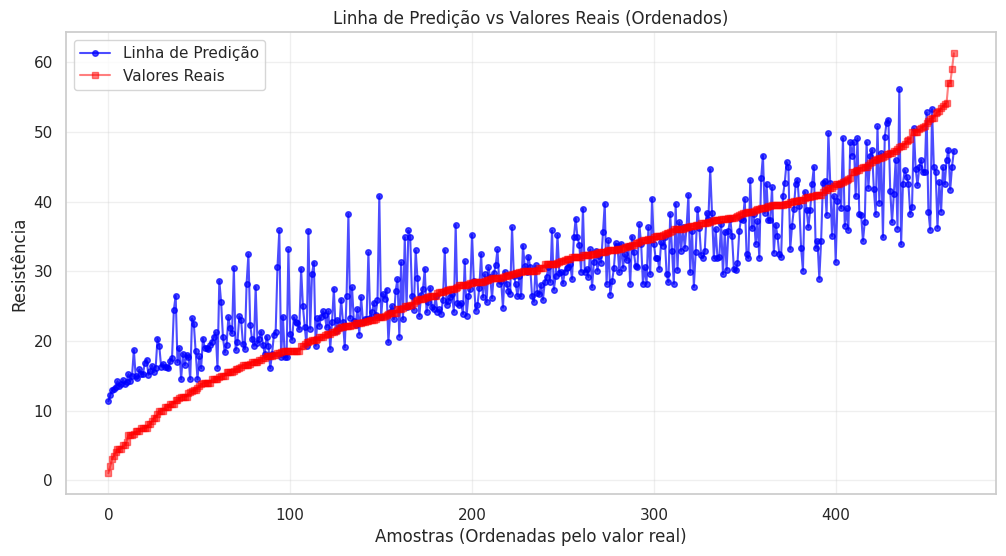

In [ ]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lasso_results.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

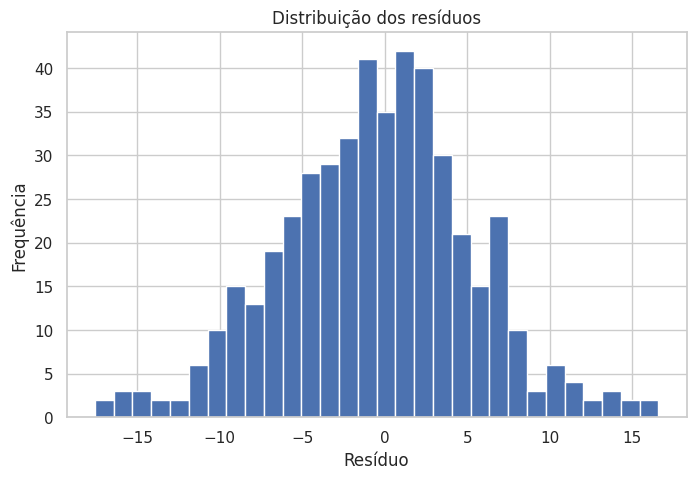

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    lasso_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

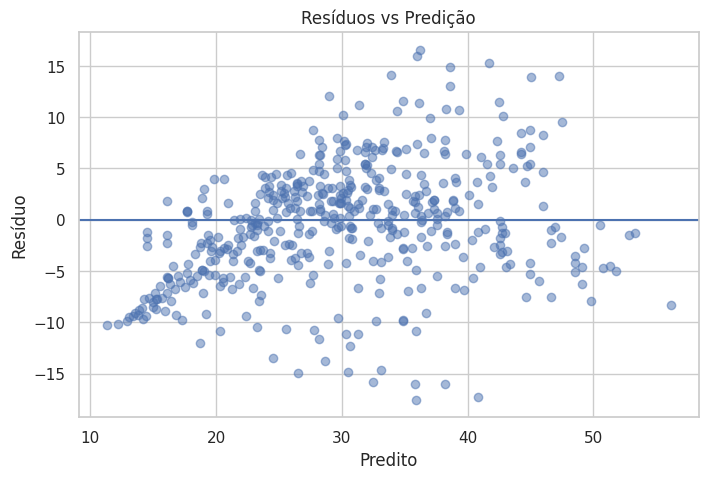

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    lasso_results["y_pred"],
    lasso_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

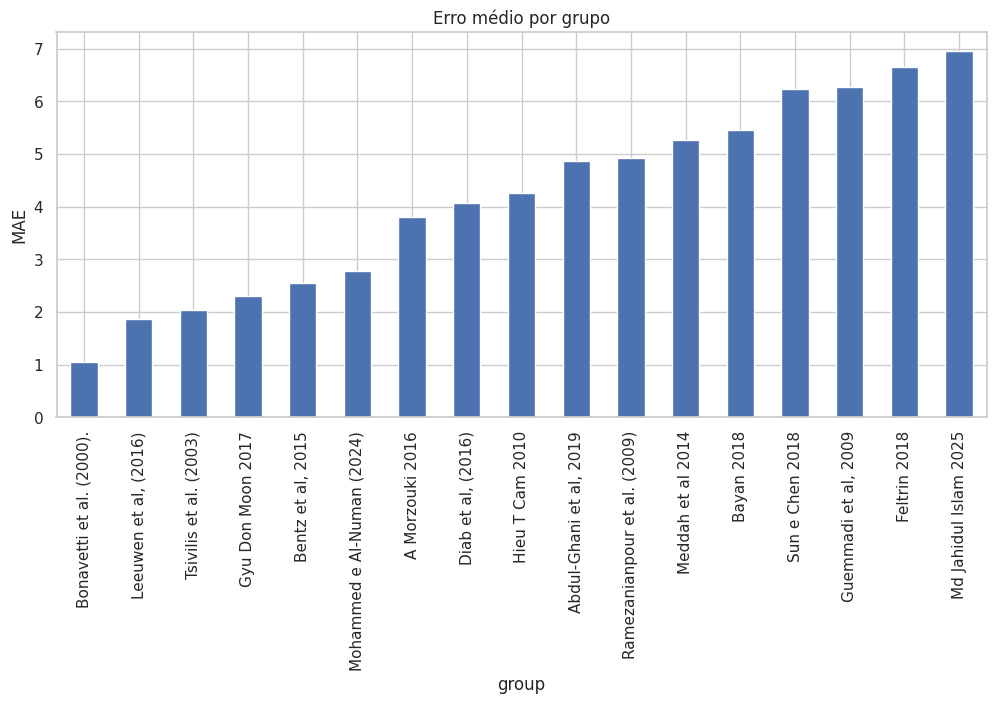

In [ ]:
group_errors = (
    lasso_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [ ]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.8038
mean_absolute_error: 4.5201
mean_absolute_percentage_error: 0.2720
R² Score: 77.2246


## Teste com regressão Ridge

In [ ]:
X = df_ridge.drop(
    columns=["target", "Autores/ano"]
)

y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

def objective(trial):
    rmse_scores = []

    alpha = trial.suggest_float("alpha", 0.01, 1000)
    
    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler_train = StandardScaler()

        X_train = scaler_train.fit_transform(X_train)
        X_val = scaler_train.transform(X_val)

        model = Ridge(alpha=alpha, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [ ]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Ridge")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_ridge = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_ridge.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]   
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_ridge.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_ridge.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Ridge:   0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-06-07 03:37:16,659] A new study created in memory with name: Tuning_Concreto
[I 2026-06-07 03:37:16,771] Trial 0 finished with value: 5.987192348320296 and parameters: {'alpha': 785.7453116984614}. Best is trial 0 with value: 5.987192348320296.
[I 2026-06-07 03:37:16,879] Trial 1 finished with value: 5.660841629875831 and parameters: {'alpha': 494.6039440694853}. Best is trial 1 with value: 5.660841629875831.
[I 2026-06-07 03:37:16,984] Trial 2 finished with value: 5.802729725985884 and parameters: {'alpha': 615.1401683699607}. Best is trial 1 with value: 5.660841629875831.
[I 2026-06-07 03:37:17,086] Trial 3 finished with value: 5.350849604636625 and parameters: {'alpha': 56.37328549817888}. Best is trial 3 with value: 5.350849604636625.
[I 2026-06-07 03:37:17,188] Trial 4 finished with value: 5.674871296720525 and parameters: {'alpha': 506.1360609207633}. Best is trial 3 with value: 5.350849604636625.
[I 2026-06-07 03:37:17,296] Trial 5 finished with value: 5.5775573628178 an

Melhor RMSE alcançado (Cross-Validation): 5.2302
Melhores Hiperparâmetros encontrados:
  'alpha': 124.2320332587647,


In [ ]:
all_instances = []

X = df_ridge.drop(
    columns=["target", "Autores/ano"]
)

y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = Ridge(alpha=study_ridge.best_params["alpha"], random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    fold_results = df_ridge.iloc[val_idx].copy()

    fold_results["y_true"] = y_val.values
    fold_results["y_pred"] = preds
    fold_results["error"] = (
        fold_results["y_true"] - fold_results["y_pred"]
    )
    fold_results["abs_error"] = (
        fold_results["error"].abs()
    )
    fold_results["group"] = groups.iloc[val_idx].values

    all_instances.append(fold_results)

In [ ]:
all_instances[0].columns

Index(['Cimento_kg_m3', 'Usa_SP', 'Massa_Esp_Brita_kg_m3', 'vol_areia',
       'vol_brita', 'inv_a_c', 'range_granulometrico', 'pow_interacao_tempo',
       'hasselman_cinetico', 'aci_211_base_28d', 's_fib', 'fib_fator_tempo',
       'bolomey_nucleo_linear', 'fib_estimativa_base', 'Autores/ano',
       'vol_cimento', 'vol_filer', 'Relacao_Agua_Aglomerante', 'vol_sp',
       'target', 'y_true', 'y_pred', 'error', 'abs_error', 'group'],
      dtype='object')

In [ ]:
ridge_results = pd.concat(all_instances, ignore_index=True)

debug_df['error'] = (
    debug_df['y_true'] - debug_df['y_pred']
)

debug_df['abs_error'] = (
    debug_df['error'].abs()
)

ridge_results["residual"] = (
    ridge_results["y_true"] -
    ridge_results["y_pred"]
)

ridge_results["abs_error"] = (
    ridge_results["residual"].abs()
)

## Observado vs Predito

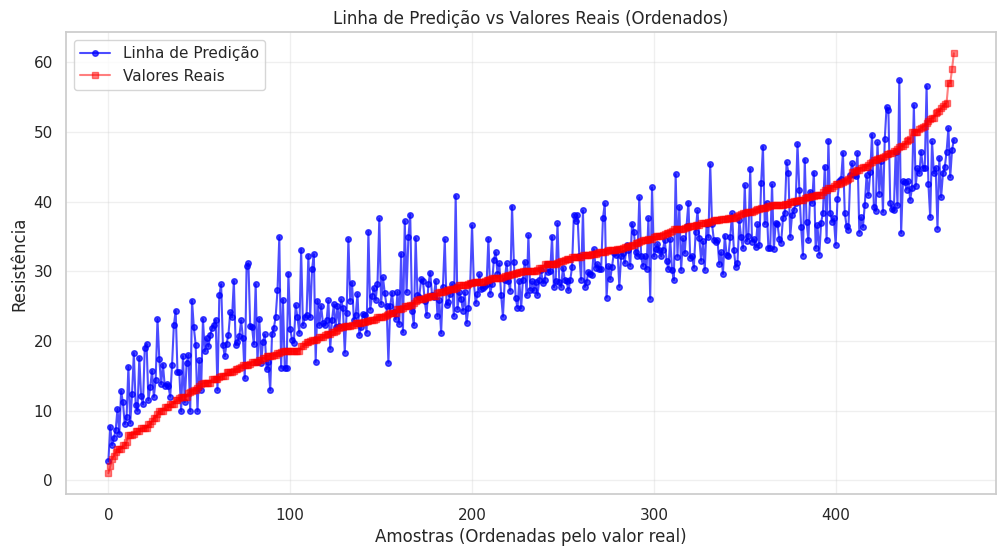

In [ ]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = ridge_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

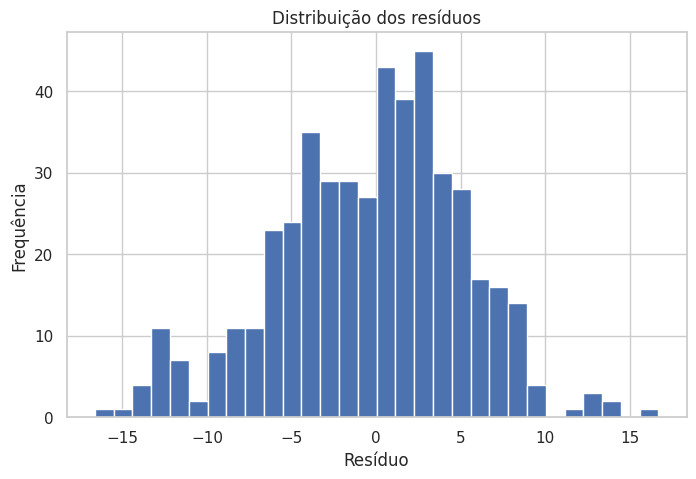

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    ridge_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

In [ ]:
debug_df.columns

Index(['Cimento_kg_m3', 'Usa_SP', 'Massa_Esp_Brita_kg_m3', 'vol_areia',
       'vol_brita', 'inv_a_c', 'range_granulometrico', 'pow_interacao_tempo',
       'hasselman_cinetico', 'aci_211_base_28d', 's_fib', 'fib_fator_tempo',
       'bolomey_nucleo_linear', 'fib_estimativa_base', 'Autores/ano',
       'vol_cimento', 'vol_filer', 'Relacao_Agua_Aglomerante', 'vol_sp',
       'target', 'y_true', 'y_pred', 'error', 'abs_error', 'group',
       'residual'],
      dtype='object')

## Residuo vs Predito

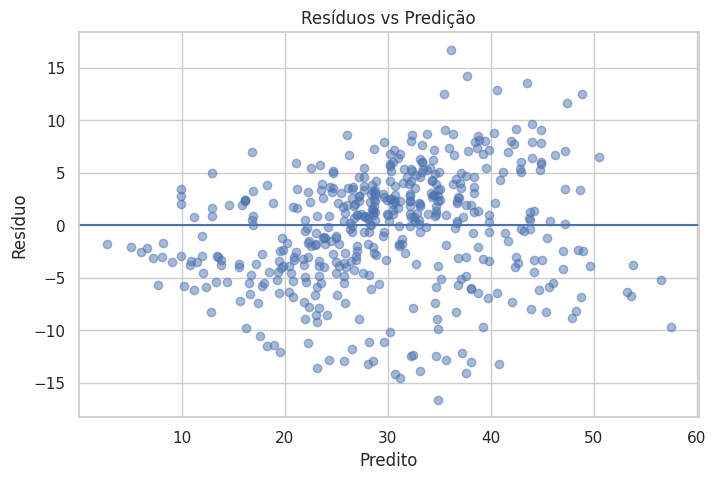

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    ridge_results["y_pred"],
    ridge_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()  

## Erro Medio por grupo

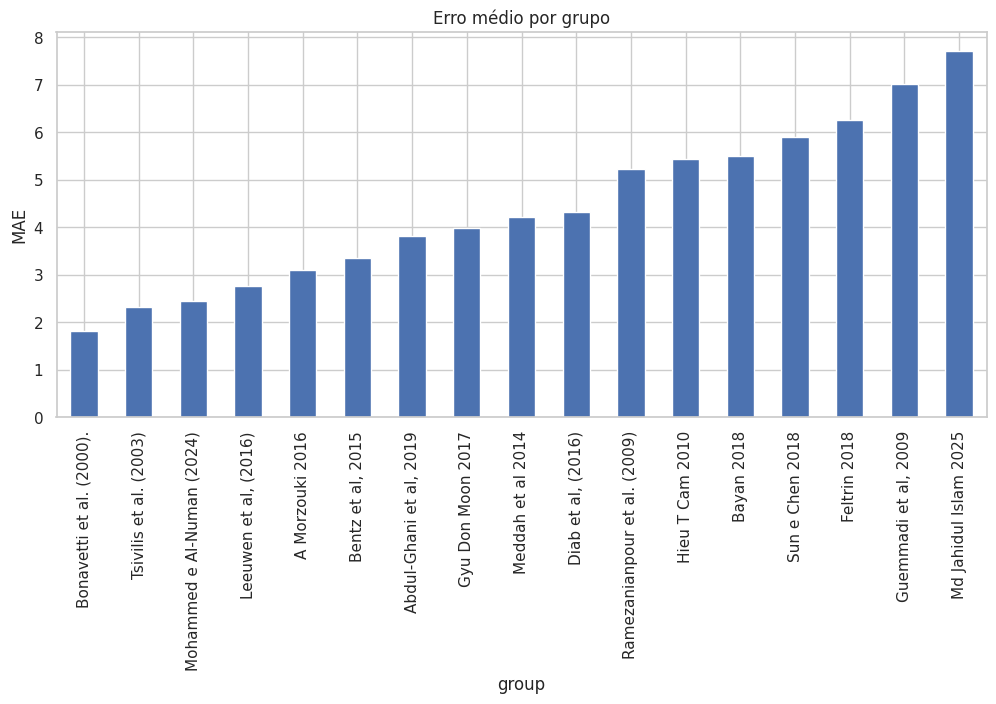

In [ ]:
group_errors = (
    ridge_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [ ]:
top_erros = (
    debug_df
    .query("abs_error > 15")
    .sort_values("abs_error", ascending=False)
)

display(top_erros)

,Cimento_kg_m3,Usa_SP,Massa_Esp_Brita_kg_m3,vol_areia,vol_brita,inv_a_c,range_granulometrico,pow_interacao_tempo,hasselman_cinetico,aci_211_base_28d,...,vol_filer,Relacao_Agua_Aglomerante,vol_sp,target,y_true,y_pred,error,abs_error,group,residual
274,284.0,True,2650.0,0.296226,0.392453,1.515152,8.689272e+19,1.020002,0.880854,38.451354,...,0.000000,0.66,0.000545,52.8,52.8,36.104037,16.695963,16.695963,Feltrin 2018,16.695963
374,304.0,False,2600.0,0.297358,0.401538,1.694915,4.789272e+03,1.240016,0.875352,42.369744,...,0.035556,0.45,0.000000,18.3,18.3,34.928081,-16.628081,16.628081,Sun e Chen 2018,-16.628081


In [ ]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.5070
mean_absolute_error: 4.3933
mean_absolute_percentage_error: 0.2173
R² Score: 79.4944


## Teste com ElasticNet

In [ ]:
X = df_elasticnet.drop(
    columns=["target", "Autores/ano"]
)

y = df_elasticnet["target"]
groups = df_elasticnet["Autores/ano"]

def objective(trial):
    rmse_scores = []

    hyperparams = {
        "alpha": trial.suggest_float("alpha", 0.01, 10),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.01, 1.0)
    }
    
    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = ElasticNet(**hyperparams, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [ ]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 100

pbar = tqdm(total=n_trials, desc="Otimizando Regressão ElasticNet")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_elasticnet = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_elasticnet.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]   
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_elasticnet.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_elasticnet.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão ElasticNet:   0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-07 03:37:52,902] A new study created in memory with name: Tuning_Concreto
[I 2026-06-07 03:37:53,011] Trial 0 finished with value: 6.302558782919309 and parameters: {'alpha': 2.4196673147778798, 'l1_ratio': 0.11400521538155253}. Best is trial 0 with value: 6.302558782919309.
[I 2026-06-07 03:37:53,123] Trial 1 finished with value: 8.093897050432057 and parameters: {'alpha': 7.05008619440147, 'l1_ratio': 0.14409762336900825}. Best is trial 0 with value: 6.302558782919309.
[I 2026-06-07 03:37:53,220] Trial 2 finished with value: 7.84256980539273 and parameters: {'alpha': 6.162724742151909, 'l1_ratio': 0.1327338185777908}. Best is trial 0 with value: 6.302558782919309.
[I 2026-06-07 03:37:53,325] Trial 3 finished with value: 6.785982199596726 and parameters: {'alpha': 3.279941998026706, 'l1_ratio': 0.35560205251700555}. Best is trial 0 with value: 6.302558782919309.
[I 2026-06-07 03:37:53,422] Trial 4 finished with value: 6.6674992740993835 and parameters: {'alpha': 3.104239951

Melhor RMSE alcançado (Cross-Validation): 4.8630
Melhores Hiperparâmetros encontrados:
  'alpha': 0.17514885590653548,
  'l1_ratio': 0.6933172680106084,


In [ ]:
all_preds = []
all_true = []
all_groups = []

X = df_elasticnet.drop(
    columns=["target", "Autores/ano"]
)

y = df_elasticnet["target"]
groups = df_elasticnet["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = ElasticNet(**study_elasticnet.best_params, random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [ ]:
elasticnet_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

elasticnet_results["residual"] = (
    elasticnet_results["y_true"] -
    elasticnet_results["y_pred"]
)

elasticnet_results["abs_error"] = (
    elasticnet_results["residual"].abs()
)

## Observado vs Predito

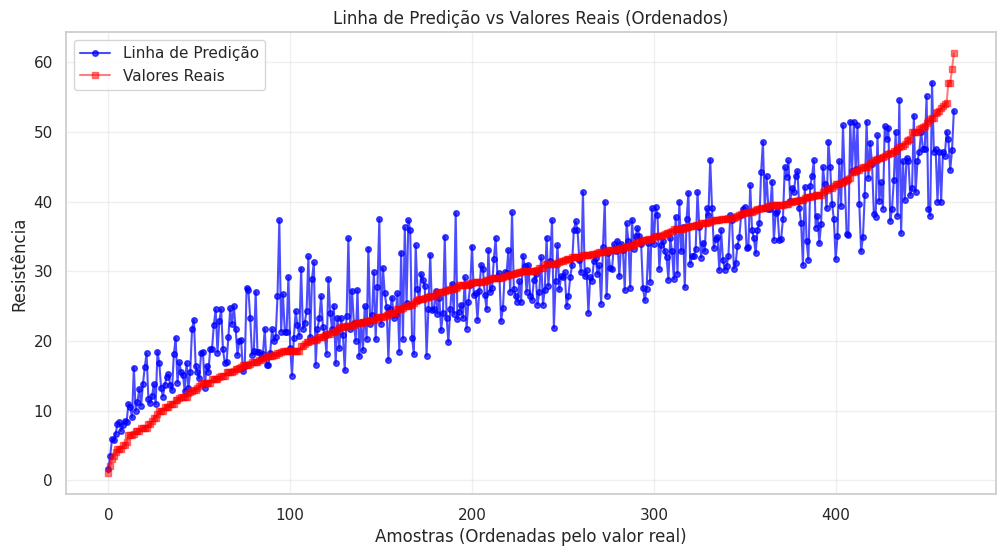

In [ ]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = elasticnet_results.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

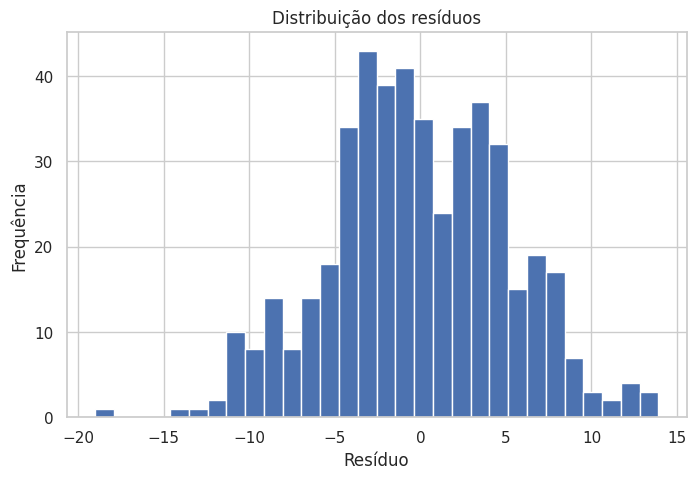

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    elasticnet_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

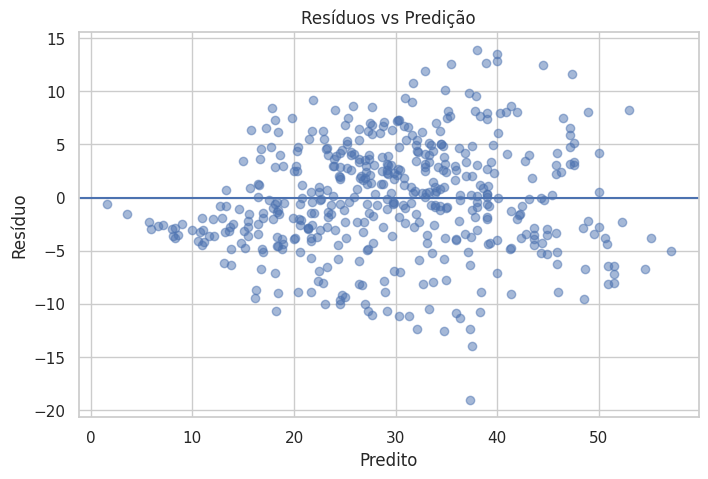

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    elasticnet_results["y_pred"],
    elasticnet_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

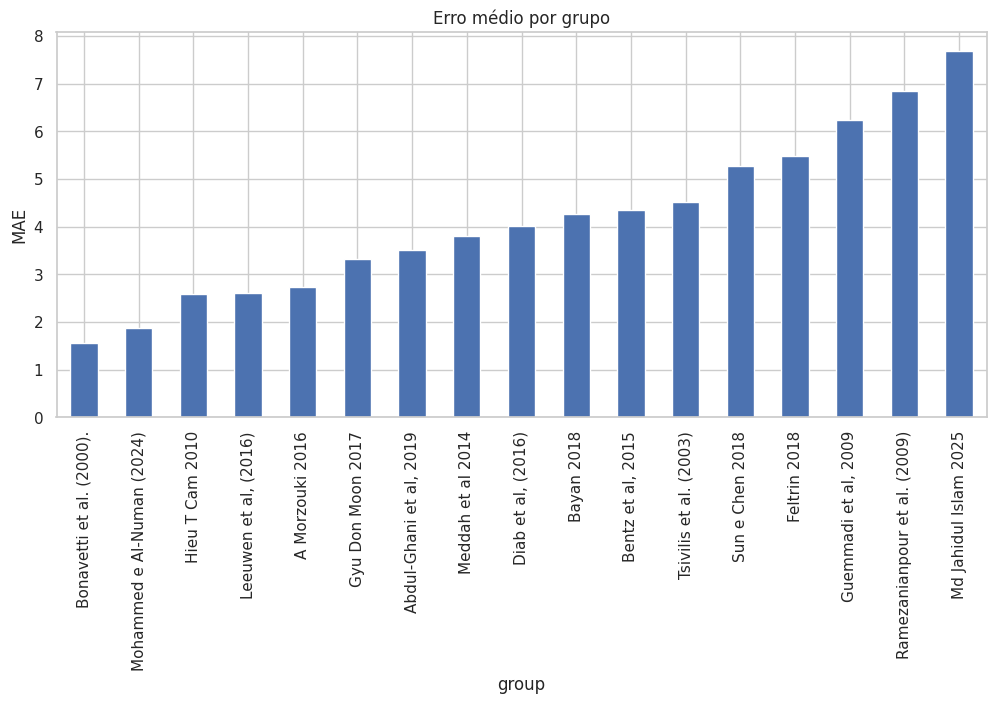

In [ ]:
group_errors = (
    elasticnet_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [ ]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.2103
mean_absolute_error: 4.1732
mean_absolute_percentage_error: 0.1880
R² Score: 81.6449
